In [39]:
import sys 
import os

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from fairchem.core.datasets import AseDBDataset
from sklearn.preprocessing import StandardScaler

In [40]:
parent_dir = os.path.abspath(os.path.join('..'))
sys.path.append(parent_dir)

In [41]:
from read_multi_ase import *

In [42]:
files_list = find_files('../../data')
print(len(files_list))

max_molcules = 10000

full_dataset = process_file(files_list, molecule_type=None, max_molecules=max_molcules)
subset = full_dataset[:500] # first 500 entries 

80


In [43]:
# confirm size of dataset 
print(len(full_dataset))
print(len(subset))

10000
500


In [46]:
def get_mol_types(dataset): 
    # initialize  
    n = len(dataset)
    atom_types = np.empty(n, dtype=object)
    
    for idx in range(n): 
        atom_types[idx] = dataset[idx, 0].info['data_id']
    
    labels, counts = np.unique(atom_types, return_counts=True)
    
    return labels, counts

In [47]:
labels, counts = get_mol_types(full_dataset)

In [48]:
labels

array(['ani2x', 'biomolecules', 'elytes', 'geom_orca6', 'metal_complexes',
       'orbnet_denali', 'reactivity', 'rgd', 'spice', 'trans1x'],
      dtype=object)

In [49]:
counts

array([ 538, 2054, 1962,  520, 1966,  129, 1973,  199,  107,  552])

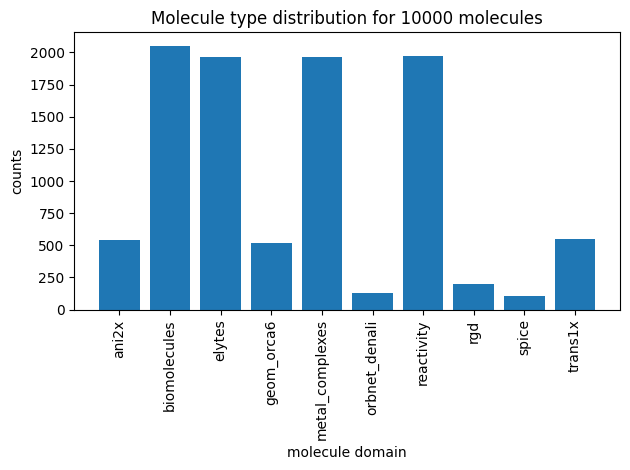

In [50]:
plt.bar(labels, counts)
plt.xlabel('molecule domain')
plt.xticks(rotation=90)
plt.ylabel('counts')
plt.title(f'Molecule type distribution for {max_molcules} molecules')
plt.tight_layout()
plt.show()

In [51]:
def get_mol_sizes(dataset): 
    # initialize  
    n = len(dataset)
    atom_counts = np.empty(n, dtype=object)
    
    for idx in range(n): 
        atom_counts[idx] = dataset[idx, 0].info['num_atoms']
    
    return atom_counts

In [52]:
atom_counts = get_mol_sizes(subset)

<Axes: ylabel='Density'>

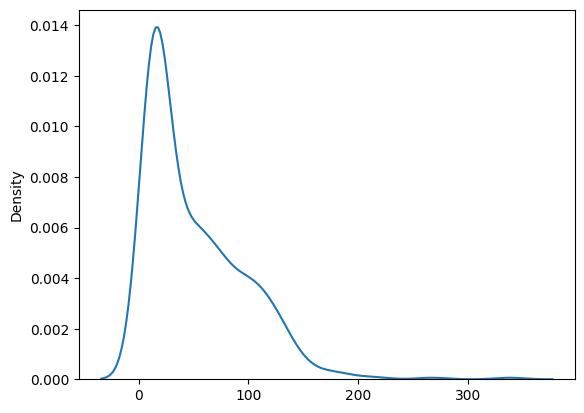

In [53]:
sns.kdeplot(atom_counts)

In [57]:
def visualize_distributions(dataset): 

    num_molecules = len(dataset)

    labels, counts = get_mol_types(dataset)
    atom_counts = get_mol_sizes(dataset)
    # print(len(labels), len(atom_counts))

    mol_types = np.repeat(labels, counts)
    
    # bar plot for mol types 
    plt.bar(labels, counts)
    plt.xlabel('molecule domain')
    plt.xticks(rotation=90)
    plt.ylabel('counts')
    plt.title(f'Molecule type distribution for {num_molecules} molecules')
    plt.tight_layout()
    plt.show()

    # plot size distribution for all molecule types 
    sns.kdeplot(x=atom_counts)
    plt.xlabel('number of atoms')
    plt.ylabel('density')
    plt.title(f'KDE for {num_molecules} molecules (all types)')
    plt.show()
    
    # plot size distribution for all molecule types 
    for label in labels:
        # get index where true 
        idx = (mol_types == label)
        sns.kdeplot(x=atom_counts[idx], label=label, alpha=0.6)

    plt.xlabel('number of atoms')
    plt.ylabel('density')
    plt.title(f'KDE for {num_molecules} molecules (by types)')
    plt.legend()
    plt.show()

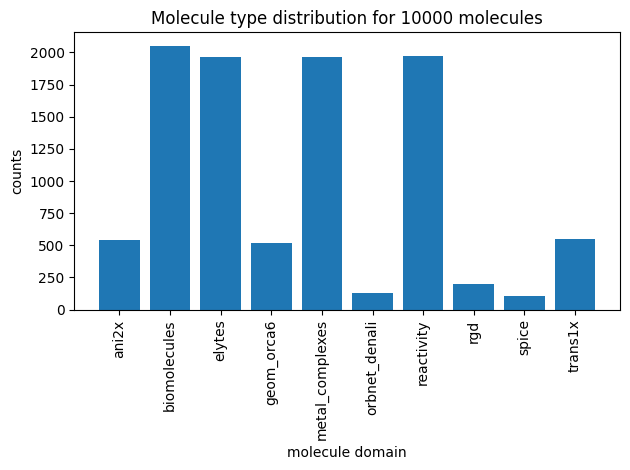

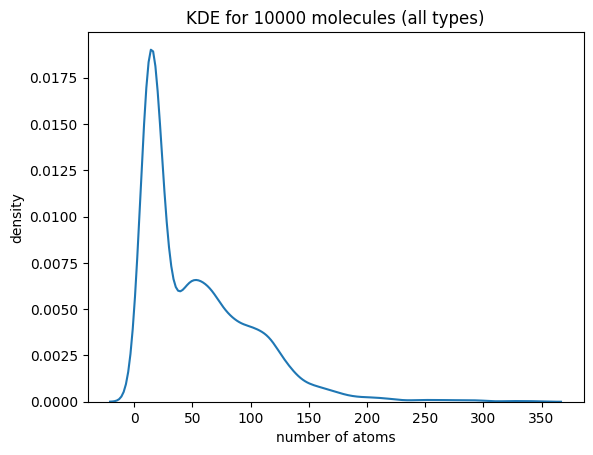

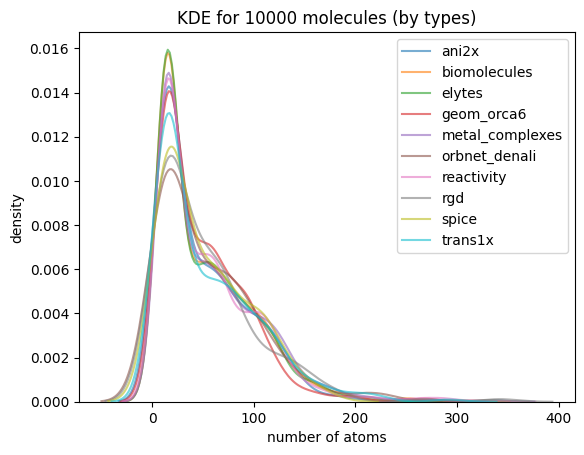

In [58]:
visualize_distributions(full_dataset)